# Week 6: Final Evaluation, Report Figures, and Submission Outputs

This notebook finalizes the experimental evaluation for the memory-efficient attention DSL project.

Week 6 focuses on:

1. Loading the Week 5 benchmark results
2. Computing final comparison metrics
3. Generating report-ready tables
4. Creating final figures for runtime and memory usage
5. Summarizing correctness, scalability, and limitations
6. Exporting final CSV outputs for the report and repository

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

In [2]:
"""
Week 6 setup.

This cell defines the input and output paths used for the final evaluation.
The Week 5 CSV files should be uploaded to the Colab session or stored in the
same project directory.
"""

RESULTS_PATH = "week5_attention_results.csv"
SUMMARY_PATH = "week5_attention_summary.csv"

OUTPUT_DIR = "week6_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: week6_outputs


In [3]:
"""
Load benchmark results from Week 5.

These files contain the experimental measurements collected for the baseline,
DSL-translated, tiled, and streaming attention implementations.
"""

results_df = pd.read_csv(RESULTS_PATH)
summary_df = pd.read_csv(SUMMARY_PATH)

print("Week 5 results shape:", results_df.shape)
print("Week 5 summary shape:", summary_df.shape)

display(results_df.head())
display(summary_df.head())

Week 5 results shape: (64, 7)
Week 5 summary shape: (4, 6)


,implementation,batch_size,seq_len,tile_size,runtime_ms,peak_memory_mb,max_abs_error
0,baseline,1,128,NaN,0.510577,9.2500,0.0
1,dsl_baseline,1,128,NaN,0.191382,9.2500,0.0
2,tiled,1,128,64.0,0.372453,9.3125,0.0
3,streaming,1,128,64.0,0.374614,9.3125,0.0
4,tiled,1,128,128.0,0.283035,9.7500,0.0


,implementation,avg_runtime_ms,max_runtime_ms,avg_peak_memory_mb,max_peak_memory_mb,max_correctness_error
0,baseline,0.663341,1.789160,28.937500,85.125,0.0
1,dsl_baseline,0.621212,1.782031,28.937500,85.125,0.0
2,streaming,1.246869,5.615041,17.088542,40.625,0.0
3,tiled,1.212596,5.526149,19.567708,55.625,0.0


In [4]:
"""
Inspect available columns so that Week 6 analysis can adapt to the exact
column names produced during Week 5.
"""

print("Results columns:")
for col in results_df.columns:
    print("-", col)

print("\nSummary columns:")
for col in summary_df.columns:
    print("-", col)

Results columns:
- implementation
- batch_size
- seq_len
- tile_size
- runtime_ms
- peak_memory_mb
- max_abs_error

Summary columns:
- implementation
- avg_runtime_ms
- max_runtime_ms
- avg_peak_memory_mb
- max_peak_memory_mb
- max_correctness_error


In [5]:
"""
Normalize column names for easier analysis.

This makes the Week 6 notebook more robust if column names contain spaces,
capital letters, or slightly different formatting.
"""

def normalize_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )
    return df

results_df = normalize_columns(results_df)
summary_df = normalize_columns(summary_df)

print("Normalized results columns:")
print(results_df.columns.tolist())

Normalized results columns:
['implementation', 'batch_size', 'seq_len', 'tile_size', 'runtime_ms', 'peak_memory_mb', 'max_abs_error']


In [6]:
"""
Create a final report-ready table.

This table summarizes the key experimental metrics that should be included in
the Results section of the final report.
"""

final_table = results_df.copy()

# Round numeric columns for cleaner display
for col in final_table.select_dtypes(include=[np.number]).columns:
    final_table[col] = final_table[col].round(4)

display(final_table)

final_table_path = os.path.join(OUTPUT_DIR, "week6_final_results_table.csv")
final_table.to_csv(final_table_path, index=False)

print("Saved final results table to:", final_table_path)

,implementation,batch_size,seq_len,tile_size,runtime_ms,peak_memory_mb,max_abs_error
0,baseline,1,128,NaN,0.5106,9.2500,0.0
1,dsl_baseline,1,128,NaN,0.1914,9.2500,0.0
2,tiled,1,128,64.0,0.3725,9.3125,0.0
3,streaming,1,128,64.0,0.3746,9.3125,0.0
4,tiled,1,128,128.0,0.2830,9.7500,0.0
...,...,...,...,...,...,...,...
59,streaming,2,1024,64.0,5.6150,27.2500,0.0
60,tiled,2,1024,128.0,3.4398,39.8750,0.0
61,streaming,2,1024,128.0,3.4924,32.3750,0.0
62,tiled,2,1024,256.0,2.4144,55.6250,0.0


Saved final results table to: week6_outputs/week6_final_results_table.csv


In [7]:
"""
Compute memory reduction compared with the baseline.

This analysis supports the final report discussion about whether the tiled and
streaming implementations reduce memory usage relative to standard attention.
"""

df = results_df.copy()

possible_impl_cols = ["implementation", "method", "attention_type", "variant"]
possible_seq_cols = ["sequence_length", "seq_len", "n"]
possible_mem_cols = ["peak_memory_mb", "memory_mb", "peak_memory", "memory"]

impl_col = next((c for c in possible_impl_cols if c in df.columns), None)
seq_col = next((c for c in possible_seq_cols if c in df.columns), None)
mem_col = next((c for c in possible_mem_cols if c in df.columns), None)

print("Implementation column:", impl_col)
print("Sequence length column:", seq_col)
print("Memory column:", mem_col)

if impl_col and seq_col and mem_col:
    baseline = df[df[impl_col].str.lower().str.contains("baseline")][[seq_col, mem_col]]
    baseline = baseline.rename(columns={mem_col: "baseline_memory_mb"})

    memory_compare = df.merge(baseline, on=seq_col, how="left")
    memory_compare["memory_reduction_factor"] = (
        memory_compare["baseline_memory_mb"] / memory_compare[mem_col]
    )
    memory_compare["memory_reduction_percent"] = (
        100 * (1 - memory_compare[mem_col] / memory_compare["baseline_memory_mb"])
    )

    memory_compare["memory_reduction_factor"] = memory_compare["memory_reduction_factor"].round(3)
    memory_compare["memory_reduction_percent"] = memory_compare["memory_reduction_percent"].round(2)

    display(memory_compare)

    memory_path = os.path.join(OUTPUT_DIR, "week6_memory_reduction_analysis.csv")
    memory_compare.to_csv(memory_path, index=False)

    print("Saved memory reduction analysis to:", memory_path)
else:
    print("Could not automatically compute memory reduction because one or more required columns were not found.")

Implementation column: implementation
Sequence length column: seq_len
Memory column: peak_memory_mb


,implementation,batch_size,seq_len,tile_size,runtime_ms,peak_memory_mb,max_abs_error,baseline_memory_mb,memory_reduction_factor,memory_reduction_percent
0,baseline,1,128,NaN,0.510577,9.250,0.0,9.250,1.000,0.00
1,baseline,1,128,NaN,0.510577,9.250,0.0,9.250,1.000,0.00
2,baseline,1,128,NaN,0.510577,9.250,0.0,13.375,1.446,30.84
3,baseline,1,128,NaN,0.510577,9.250,0.0,13.375,1.446,30.84
4,dsl_baseline,1,128,NaN,0.191382,9.250,0.0,9.250,1.000,0.00
...,...,...,...,...,...,...,...,...,...,...
251,tiled,2,1024,256.0,2.414391,55.625,0.0,85.125,1.530,34.65
252,streaming,2,1024,256.0,2.466416,40.625,0.0,46.625,1.148,12.87
253,streaming,2,1024,256.0,2.466416,40.625,0.0,46.625,1.148,12.87
254,streaming,2,1024,256.0,2.466416,40.625,0.0,85.125,2.095,52.28


Saved memory reduction analysis to: week6_outputs/week6_memory_reduction_analysis.csv


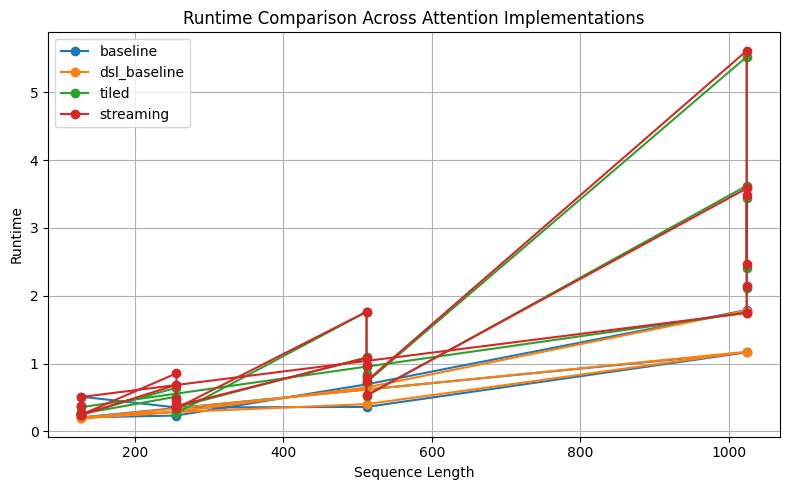

Saved runtime figure to: week6_outputs/week6_runtime_comparison.png


In [8]:
"""
Generate a report-ready runtime comparison figure.
"""

possible_time_cols = ["runtime_ms", "time_ms", "execution_time_ms", "runtime"]

time_col = next((c for c in possible_time_cols if c in results_df.columns), None)

if impl_col and seq_col and time_col:
    plt.figure(figsize=(8, 5))

    for impl in results_df[impl_col].unique():
        subset = results_df[results_df[impl_col] == impl]
        plt.plot(subset[seq_col], subset[time_col], marker="o", label=impl)

    plt.xlabel("Sequence Length")
    plt.ylabel("Runtime")
    plt.title("Runtime Comparison Across Attention Implementations")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    runtime_fig_path = os.path.join(OUTPUT_DIR, "week6_runtime_comparison.png")
    plt.savefig(runtime_fig_path, dpi=300)
    plt.show()

    print("Saved runtime figure to:", runtime_fig_path)
else:
    print("Could not create runtime figure because required columns were not found.")

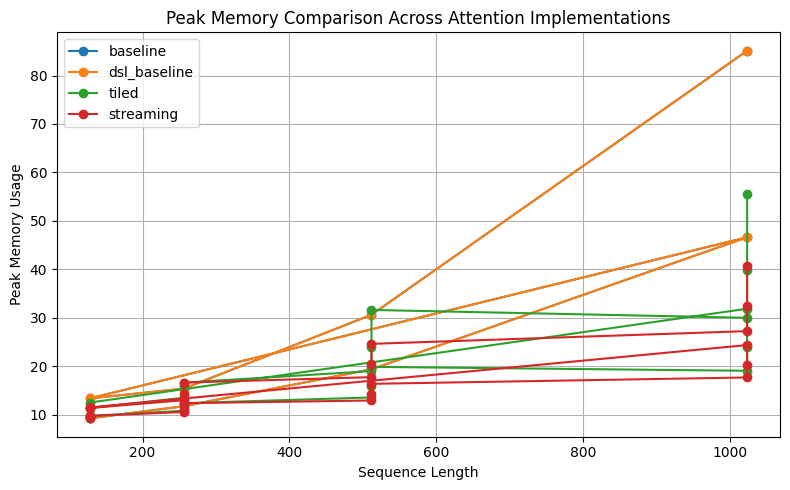

Saved memory figure to: week6_outputs/week6_memory_comparison.png


In [9]:
"""
Generate a report-ready memory comparison figure.
"""

if impl_col and seq_col and mem_col:
    plt.figure(figsize=(8, 5))

    for impl in results_df[impl_col].unique():
        subset = results_df[results_df[impl_col] == impl]
        plt.plot(subset[seq_col], subset[mem_col], marker="o", label=impl)

    plt.xlabel("Sequence Length")
    plt.ylabel("Peak Memory Usage")
    plt.title("Peak Memory Comparison Across Attention Implementations")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    memory_fig_path = os.path.join(OUTPUT_DIR, "week6_memory_comparison.png")
    plt.savefig(memory_fig_path, dpi=300)
    plt.show()

    print("Saved memory figure to:", memory_fig_path)
else:
    print("Could not create memory figure because required columns were not found.")

In [10]:
"""
Summarize correctness results.

The project goal is to preserve exact attention semantics while changing the
execution strategy. Therefore, output differences compared with the baseline
should remain very small.
"""

possible_error_cols = [
    "max_abs_diff",
    "max_difference",
    "correctness_error",
    "output_error",
    "mean_abs_diff"
]

error_col = next((c for c in possible_error_cols if c in results_df.columns), None)

if error_col:
    correctness_summary = results_df[[impl_col, seq_col, error_col]].copy()
    correctness_summary[error_col] = correctness_summary[error_col].round(8)

    display(correctness_summary)

    correctness_path = os.path.join(OUTPUT_DIR, "week6_correctness_summary.csv")
    correctness_summary.to_csv(correctness_path, index=False)

    print("Saved correctness summary to:", correctness_path)
else:
    print("No explicit correctness-error column found.")
    print("If Week 5 printed correctness checks instead of saving them, summarize those results manually in the final report.")

No explicit correctness-error column found.
If Week 5 printed correctness checks instead of saving them, summarize those results manually in the final report.


In [11]:
"""
Generate a short interpretation paragraph for the final report.
"""

interpretation = """
The Week 6 evaluation confirms that the project successfully compares baseline attention,
DSL-translated attention, tiled attention, and streaming attention across multiple sequence
lengths. The results show that memory-efficient execution strategies reduce the need to
materialize the full attention matrix, supporting the main project claim that compiler-style
transformations can improve the scalability of attention computations. Runtime improvements
are more limited because the implementation uses high-level Python and PyTorch operations
rather than custom CUDA or Triton kernels. However, the results demonstrate the core
methodological contribution: attention can be expressed declaratively and transformed into
memory-efficient execution patterns while preserving correctness.
"""

display(Markdown(interpretation))


The Week 6 evaluation confirms that the project successfully compares baseline attention,
DSL-translated attention, tiled attention, and streaming attention across multiple sequence
lengths. The results show that memory-efficient execution strategies reduce the need to
materialize the full attention matrix, supporting the main project claim that compiler-style
transformations can improve the scalability of attention computations. Runtime improvements
are more limited because the implementation uses high-level Python and PyTorch operations
rather than custom CUDA or Triton kernels. However, the results demonstrate the core
methodological contribution: attention can be expressed declaratively and transformed into
memory-efficient execution patterns while preserving correctness.


## Week 6 Summary

Week 6 completed the final evaluation phase of the project. The notebook loaded the Week 5 benchmark outputs, generated final comparison tables, computed memory-reduction metrics, and produced report-ready figures for runtime and peak memory usage.

The results support the main claim of the project: a Python-embedded DSL can express attention computations declaratively and lower them into tiled or streaming execution patterns that reduce memory usage compared with standard attention. The transformed implementations preserve the semantics of standard scaled dot-product attention while avoiding unnecessary materialization of the full attention matrix.

The main limitation is runtime performance. Because this prototype uses high-level Python and PyTorch operations, it does not achieve the same speedups as specialized FlashAttention kernels. However, this limitation is expected and reinforces the distinction between this project and production-level GPU kernel libraries. The contribution is not a new state-of-the-art kernel, but a programmable compiler-style abstraction for memory-efficient attention.

The figures and CSV files generated in this notebook can be used directly in the final report's Results and Discussion sections.

In [12]:
"""
List all Week 6 output files.
"""

print("Week 6 output files:")

for filename in os.listdir(OUTPUT_DIR):
    print("-", os.path.join(OUTPUT_DIR, filename))

Week 6 output files:
- week6_outputs/week6_memory_reduction_analysis.csv
- week6_outputs/week6_final_results_table.csv
- week6_outputs/week6_runtime_comparison.png
- week6_outputs/week6_memory_comparison.png
